In [2]:
import joblib
import pandas as pd
import numpy as np
from feature_eng import TSFE
import logging 
import warnings
import matplotlib.pyplot as plt
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)

# trained default model
pu_clf = joblib.load('default_model.joblib')


In [ ]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

target ='label1'

feature_cols= [
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
    'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
    'CH4_start_level', 'CH4_end_level', #'duration', 
    'is_air','is_std',
    #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
    ]
#
# only select the feature include in feature_cols
X = df[feature_cols]
y = df[target]

# 80% training, 20% testing(time-series data, split by time)
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


print('Feature eng...')

#feature eng
tsfe = TSFE(feature_cols=feature_cols)
X_train_final = tsfe.transform(X_train)

X_test_final = tsfe.transform(X_test)

# features we will use in model training
feature_ml =  ['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_end_time',
 'CH4_w_residual_6h',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_residual_24h',
 'CH4_ht_residual_1h',
 'CH4_w_diff_1',
 'CH4_w',
 'CH4_start_time',
 'CH4_area_to_last_air_ratio']


X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

Feature eng...


In [7]:
def predict_proba_pu (models, X):
    """
    Args:
        models(List): List containing trained sub-models
        X(pd.DataFrame):Data for prediction
    Returns:
        np.ndarray: Mean anomaly probability for the positive class (labeled 1) across all sub-models
    """
    probs = [m.predict_proba(X)[:, 1] for m in models]
    return np.mean(probs, axis=0)

In [ ]:
# if anomaly probability > 0.8, classified as 1 (anomaly)
threshold = 0.8
y_prob_pu = predict_proba_pu (pu_clf, X_test_final)
y_pred_pu = (y_prob_pu>= threshold).astype(int)

In [ ]:
# create result df with predicted class and anomaly probability
result_df = pd.concat([
    X_test.drop(columns=['is_air', 'is_std']),
    pd.Series(y_prob_pu, index=X_test.index, name='prob_pu'),
    pd.Series(y_pred_pu, index=X_test.index, name='pred_pu')
], axis=1)

result_df.head()

,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,prob_pu,pred_pu
datetime,,,,,,,,,,,,,,
2019-08-23 08:24:00,air,816.2,40.0,102.4,7.42,144272.0,1249804.0,0.93,88.2,141.2,29258.0,29755.0,0.152018,0
2019-08-23 08:44:00,std,815.1,40.0,102.4,7.42,144431.0,1252019.0,0.93,88.4,141.2,29323.0,29780.0,0.126532,0
2019-08-23 09:04:00,air,816.0,40.0,102.4,7.44,144621.0,1254891.0,0.93,88.2,141.2,29299.0,29781.0,0.053040,0
2019-08-23 09:24:00,std,814.8,40.0,102.4,7.45,144525.0,1258433.0,0.92,88.2,141.2,29305.0,29660.0,0.141091,0
2019-08-23 09:44:00,air,816.1,40.0,102.4,7.44,145376.0,1262486.0,0.92,88.2,141.2,29327.0,29818.0,0.222780,0


In [12]:
final_df = result_df.sort_values(by='prob_pu', ascending=False) 
final_df.head()

,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,prob_pu,pred_pu
datetime,,,,,,,,,,,,,,
2021-04-06 12:23:00,air,826.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996074,1
2021-04-06 12:43:00,std,822.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996074,1
2023-04-09 06:25:00,air,806.3,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996074,1
2023-04-09 11:46:00,air,804.8,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996074,1
2023-04-09 11:26:00,std,816.1,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.996074,1


In [ ]:
final_df.to_csv('anomaly_prediction.csv') # Save anomaly prediction results

In [ ]:
# create df to store fp data
result_df_fp= pd.concat([
    X_test.drop(columns=['is_air', 'is_std']),
    pd.Series(y_test, index=X_test.index, name='y_true'),
    pd.Series(y_prob_pu, index=X_test.index, name='prob_pu'),
    pd.Series(y_pred_pu, index=X_test.index, name='pred_pu')
], axis=1)


result_df.head()

,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,prob_pu,pred_pu
datetime,,,,,,,,,,,,,,
2019-08-23 08:24:00,air,816.2,40.0,102.4,7.42,144272.0,1249804.0,0.93,88.2,141.2,29258.0,29755.0,0.152018,0
2019-08-23 08:44:00,std,815.1,40.0,102.4,7.42,144431.0,1252019.0,0.93,88.4,141.2,29323.0,29780.0,0.126532,0
2019-08-23 09:04:00,air,816.0,40.0,102.4,7.44,144621.0,1254891.0,0.93,88.2,141.2,29299.0,29781.0,0.053040,0
2019-08-23 09:24:00,std,814.8,40.0,102.4,7.45,144525.0,1258433.0,0.92,88.2,141.2,29305.0,29660.0,0.141091,0
2019-08-23 09:44:00,air,816.1,40.0,102.4,7.44,145376.0,1262486.0,0.92,88.2,141.2,29327.0,29818.0,0.222780,0


In [ ]:
# Extract fp data points
diff_df = result_df_fp[(result_df['pred_pu'] == 1) & (result_df_fp['y_true']==0)]
diff_df = diff_df.sort_values(by='prob_pu', ascending=False)

diff_df.head()

,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,y_true,prob_pu,pred_pu
datetime,,,,,,,,,,,,,,,
2025-05-24 06:41:00,air,800.6,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
2025-05-23 21:21:00,air,806.9,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
2025-05-24 08:01:00,air,800.5,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
2025-05-24 07:21:00,air,800.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
2025-05-23 22:01:00,air,801.2,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1


In [10]:
diff_df.to_csv('False_positive.csv')

=======================================

In [3]:
fp_df = pd.read_csv("False_positive.csv") 

In [4]:
fp_df.head()

,datetime,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,y_true,prob_pu,pred_pu
0,2025-05-24 06:41:00,air,800.6,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
1,2025-05-23 21:21:00,air,806.9,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
2,2025-05-24 08:01:00,air,800.5,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
3,2025-05-24 07:21:00,air,800.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1
4,2025-05-23 22:01:00,air,801.2,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.996074,1


### Plot Percentage of Zero Features (CH4_ht=0 or CH4_area =0) in FPs with anomaly Probability > 0.8

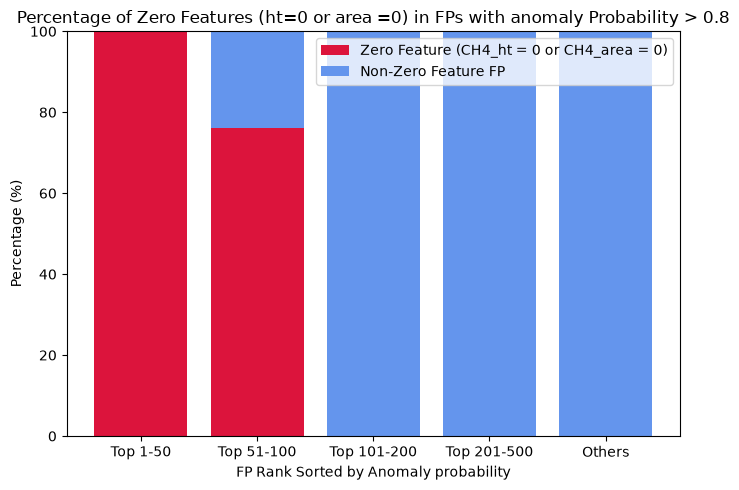

In [5]:
fp_df['is_zero'] = (fp_df["CH4_ht"] == 0)| (fp_df['CH4_area']==0)

fp_df = fp_df.sort_values(by="prob_pu", ascending=False).reset_index(drop = True)

bins = [0, 50, 100, 200, 500, max(501, len(fp_df))]
labels = ['Top 1-50', 'Top 51-100', 'Top 101-200', 'Top 201-500', 'Others']
fp_df['rank_group'] = pd.cut(
    fp_df.index, bins=bins, labels = labels, include_lowest=True
)

grouped = (
    pd.crosstab(fp_df['rank_group'], fp_df['is_zero'], normalize='index')*100
)

plt.figure(figsize=(7, 5))

plt.bar(
    grouped.index,
    grouped[True],
    color='crimson',
    label = 'Zero Feature (CH4_ht = 0 or CH4_area = 0)'
)

plt.bar(
    grouped.index,
    grouped[False],
    bottom=grouped[True],
    color='cornflowerblue',
    label='Non-Zero Feature FP'
)

plt.ylabel("Percentage (%)")
plt.xlabel("FP Rank Sorted by Anomaly probability")
plt.title("Percentage of Zero Features (ht=0 or area =0) in FPs with anomaly Probability > 0.8")
plt.legend()
plt.tight_layout()
plt.show()